In [2]:
import pandas as pd

df = pd.read_csv("sales_data.csv")
print(df.head())
print(df.info())
print(df.describe())

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
None
         Quantity      

In [3]:
# Drop missing values if any
df.dropna(inplace=True)



In [4]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

print("\nData Info:")
print(df.info())



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         100 non-null    datetime64[ns]
 1   Product      100 non-null    object        
 2   Quantity     100 non-null    int64         
 3   Price        100 non-null    int64         
 4   Customer_ID  100 non-null    object        
 5   Region       100 non-null    object        
 6   Total_Sales  100 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 5.6+ KB
None


In [5]:
# 3. Basic Analysis
# ------------------------------
total_sales = df['Total_Sales'].sum()
avg_sales = df['Total_Sales'].mean()

print("\nTotal Sales:", total_sales)
print("Average Sales:", avg_sales)

# Sales by Product
product_sales = df.groupby('Product')['Total_Sales'].sum()

# Sales by Region
region_sales = df.groupby('Region')['Total_Sales'].sum()



Total Sales: 12365048
Average Sales: 123650.48


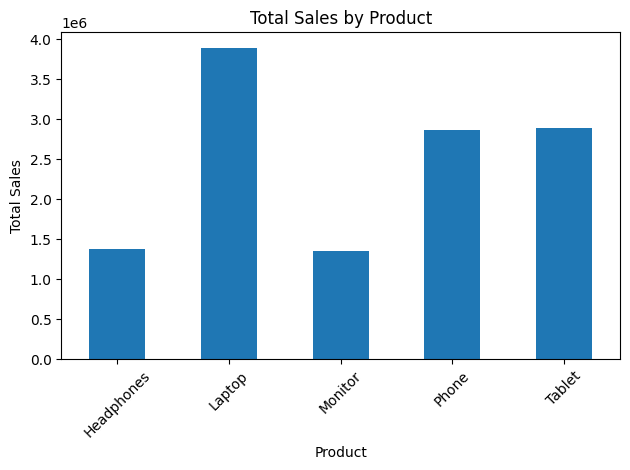

In [8]:
import matplotlib.pyplot as plt
# 4. Visualization 1: Bar Chart
# ------------------------------
plt.figure()
product_sales.plot(kind='bar')
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

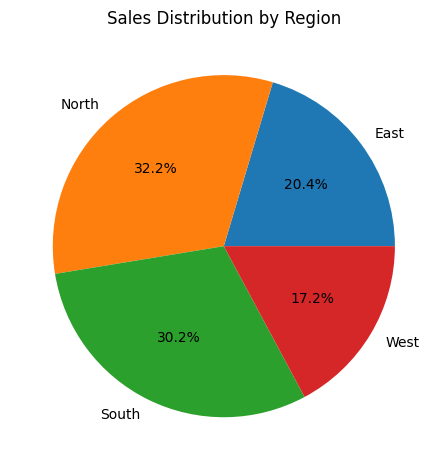

In [9]:
# ------------------------------
# 5. Visualization 2: Pie Chart
# ------------------------------
plt.figure()
region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Region")
plt.ylabel("")
plt.tight_layout()

plt.show()

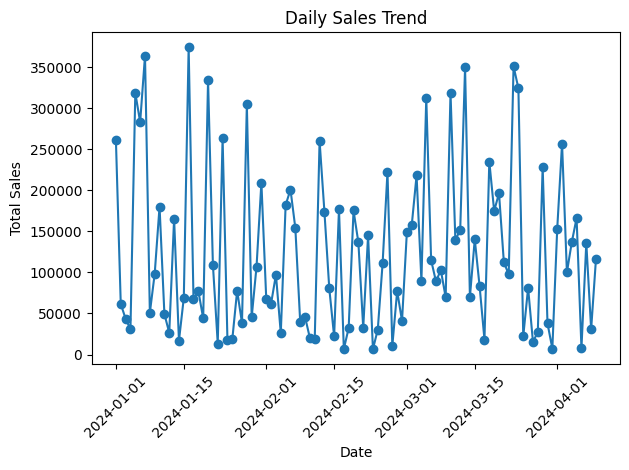

In [11]:
# 6. Trend Analysis (Line Chart)
# ------------------------------
daily_sales = df.groupby('Date')['Total_Sales'].sum()

plt.figure()
plt.plot(daily_sales.index, daily_sales.values, marker='o')
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
# 7. Insights
# ------------------------------
print("\n----- Key Insights -----")
print("1. Highest Selling Product:", product_sales.idxmax())
print("2. Region with Maximum Sales:", region_sales.idxmax())
print("3. Lowest Sales Product:", product_sales.idxmin())
print("4. Overall Sales Trend shows fluctuations over time.")


----- Key Insights -----
1. Highest Selling Product: Laptop
2. Region with Maximum Sales: North
3. Lowest Sales Product: Monitor
4. Overall Sales Trend shows fluctuations over time.
